# Análisis no supervisado en el dataset Spotify

* Objetivo

El objetivo de este notebook es el de encontrar patrones o grupos ocultos utilizando herramientas de clustering para luego realizar análisis de estos hallazgos para los futuros modelos de ML.

En esta etapa se realizan las siguientes operaciones:

* Matriz de correlación
* PCA

In [146]:
import pandas as pd
import numpy as np
import os
import sys

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split

from sklearn.metrics import calinski_harabasz_score
from sklearn.metrics import davies_bouldin_score

"""
En caso de que Python no encuentre en la ruta los otros directorios,
ejecutar esta configuración
"""

sys.path.append(os.path.abspath(".."))

In [147]:
data = pd.read_csv("../dataset/spotify_train_preprocesado.csv")

df = data.copy()

df.head()

,bin__track_genre_0,bin__track_genre_1,bin__track_genre_2,bin__track_genre_3,bin__track_genre_4,bin__track_genre_5,bin__track_genre_6,ord__duration_category,num__danceability,num__energy,...,num__loudness,num__mode,num__speechiness,num__acousticness,num__instrumentalness,num__liveness,num__valence,num__tempo,num__duration_min,popularity_category
0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,-0.360656,0.407609,0.005418,...,-0.557598,0.751125,-0.804229,0.532848,-0.562123,-0.436477,1.542740,-0.147610,-0.695300,1
1,0.0,0.0,0.0,0.0,0.0,1.0,0.0,-0.360656,0.100464,-0.034422,...,-0.017461,0.751125,-0.785413,0.623235,-0.606882,-0.678120,1.183864,0.437714,-0.191994,0
2,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.927115,-1.881489,0.216573,...,0.430609,0.751125,-0.519639,-0.618079,-0.580263,-0.985860,-1.305115,0.437984,0.625209,2
3,0.0,0.0,0.0,0.0,1.0,0.0,0.0,-0.360656,1.746296,0.336094,...,0.571210,-1.331337,-0.500823,-0.710274,-0.606882,-0.635477,-0.506326,0.064335,-0.879964,0
4,0.0,0.0,0.0,0.0,1.0,0.0,1.0,-0.360656,0.726344,-1.795371,...,-2.390784,-1.331337,1.124396,1.430692,1.793755,-0.671013,1.195440,2.664353,-0.772929,2


# 1ra pregunta: ¿Qué perfiles o tipos de canciones se pueden identificar según sus características musicales?

Primero, se realizará un chequeo de las correlaciones para lograr identificar si existen correlaciones fuertes en el dataset en base a las características de las canciones.

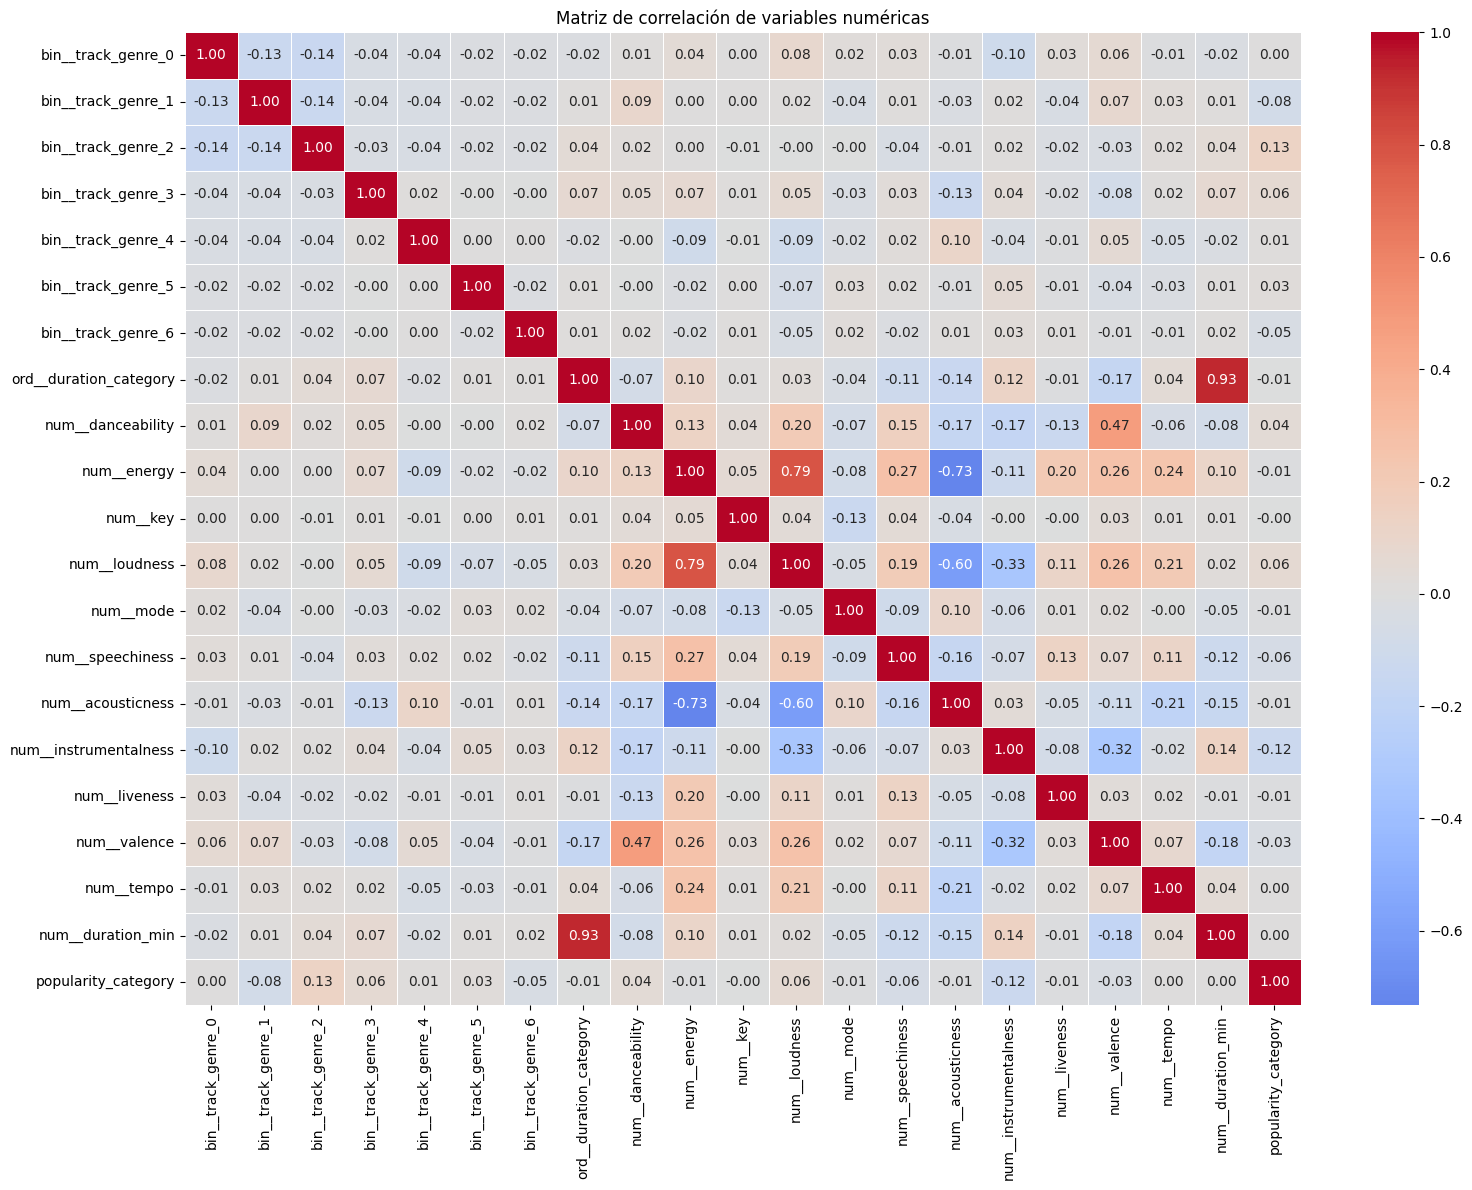

In [148]:
# Calcular matriz de correlación
matriz_correlacion = df.corr()

# Visualizar matriz
plt.figure(figsize=(16, 12))

sns.heatmap(
    matriz_correlacion,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Matriz de correlación de variables numéricas")
plt.tight_layout()
plt.show()

---

# PCA en el dataset

Con el fin de entender la importancia de las variables del dataset y reducir la dimensionalidad, se utiliza la herramienta PCA para identificar la varianza explicada por cada componente individual y la acumulada del PCA.

In [149]:
features_pca = [
    "bin__track_genre_0",
    "bin__track_genre_1",
    "bin__track_genre_2",
    "bin__track_genre_3",
    "bin__track_genre_4",
    "bin__track_genre_5",
    "bin__track_genre_6",
    "ord__duration_category",
    "num__danceability",
    "num__energy",
    "num__key",
    "num__loudness",
    "num__mode",
    "num__speechiness",
    "num__acousticness",
    "num__instrumentalness",
    "num__liveness",
    "num__valence",
    "num__tempo",
    "num__duration_min"
]

X_pca = df[features_pca]

In [150]:
pca = PCA()

X_pca_transformed = pca.fit_transform(X_pca)

In [151]:
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

for i, (individual, cumulative) in enumerate(
    zip(explained_variance, cumulative_variance),
    start=1
):
    print(
        f"PC{i}: "
        f"{individual:.2%} individual | "
        f"{cumulative:.2%} acumulada"
    )

PC1: 19.70% individual | 19.70% acumulada
PC2: 14.80% individual | 34.50% acumulada
PC3: 9.03% individual | 43.53% acumulada
PC4: 8.04% individual | 51.57% acumulada
PC5: 6.95% individual | 58.52% acumulada
PC6: 6.36% individual | 64.89% acumulada
PC7: 6.00% individual | 70.89% acumulada
PC8: 5.55% individual | 76.43% acumulada
PC9: 5.15% individual | 81.59% acumulada
PC10: 3.19% individual | 84.78% acumulada
PC11: 2.28% individual | 87.06% acumulada
PC12: 1.89% individual | 88.95% acumulada
PC13: 1.85% individual | 90.81% acumulada
PC14: 1.74% individual | 92.55% acumulada
PC15: 1.71% individual | 94.25% acumulada
PC16: 1.64% individual | 95.89% acumulada
PC17: 1.55% individual | 97.44% acumulada
PC18: 1.16% individual | 98.59% acumulada
PC19: 0.93% individual | 99.53% acumulada
PC20: 0.47% individual | 100.00% acumulada


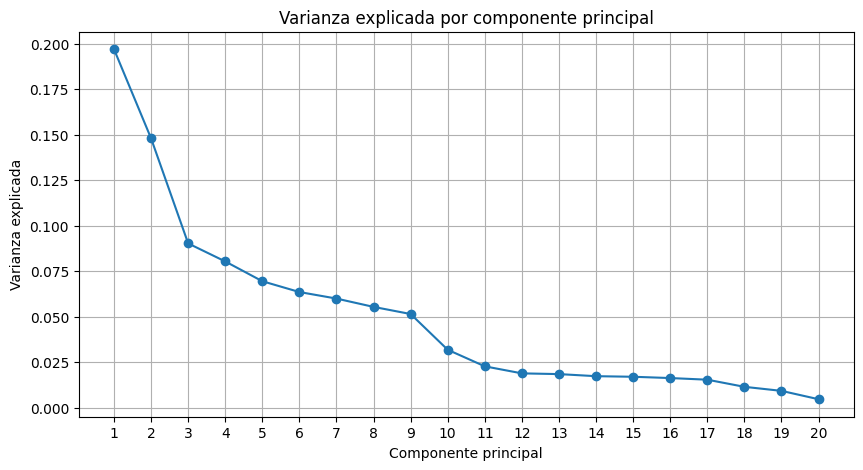

In [152]:
plt.figure(figsize=(10, 5))

plt.plot(
    range(1, len(explained_variance) + 1),
    explained_variance,
    marker="o"
)

plt.xlabel("Componente principal")
plt.ylabel("Varianza explicada")
plt.title("Varianza explicada por componente principal")
plt.xticks(range(1, len(explained_variance) + 1))
plt.grid(True)

plt.show()

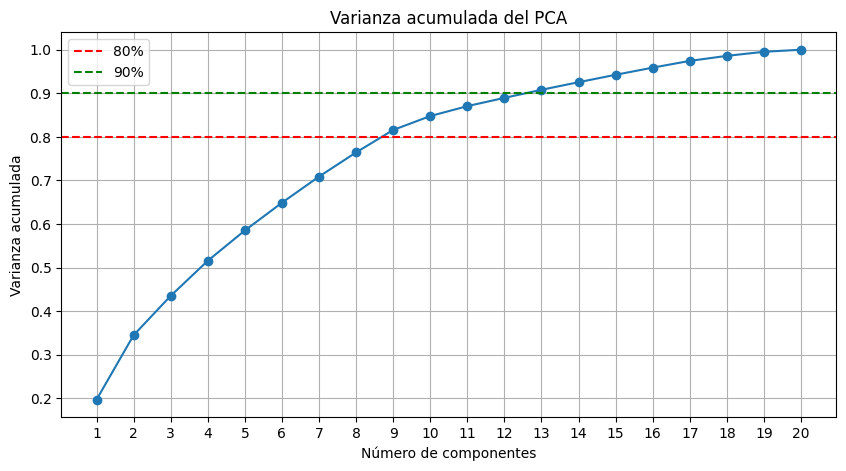

In [153]:
plt.figure(figsize=(10, 5))

plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker="o"
)

plt.axhline(
    0.80,
    color="red",
    linestyle="--",
    label="80%"
)

plt.axhline(
    0.90,
    color="green",
    linestyle="--",
    label="90%"
)

plt.xlabel("Número de componentes")
plt.ylabel("Varianza acumulada")
plt.title("Varianza acumulada del PCA")
plt.xticks(range(1, len(cumulative_variance) + 1))
plt.legend()
plt.grid(True)

plt.show()

# Selección de componentes PCA

Con el fin de seleccionar el número de componentes adecuado y **corroborar su impacto en el análisis**, se utilizarán dos dataframes con distinta cantidad de componentes los cuales se componenen de la siguiente manera:

Dataframe 1:
* Número de componentes: 9 
* Varianza acumulada: 81,59%
* Representación de datos: 45%

Dataframe 2:
* Número de componentes: 13 
* Varianza acumulada: 90,81%
* Representación de datos: 65%

In [154]:
pca1 = PCA(n_components = 9)

pca2 = PCA(n_components = 13)

X_pca_df1 = pca1.fit_transform(X_pca)

X_pca_df2 = pca2.fit_transform(X_pca)

Creación del Dataframe con los componentes

In [155]:
df_pca_1 = pd.DataFrame(
    X_pca_df1,
    columns=[f"PC{i}" for i in range(1, pca1.n_components_ + 1)],
    index=df.index
)

df_pca_1["popularity_category"] = df["popularity_category"]


df_pca_2 = pd.DataFrame(
    X_pca_df2,
    columns=[f"PC{i}" for i in range(1, pca2.n_components_ + 1)],
    index=df.index
)

df_pca_2["popularity_category"] = df["popularity_category"]

In [156]:
df_pca_1.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,popularity_category
0,-0.200809,-1.375739,1.229657,0.260928,0.175410,1.301302,-0.213395,0.526588,0.631094,1
1,-0.070853,-0.885718,0.933779,0.659522,-0.334985,1.296782,0.063861,0.117424,0.242782,0
2,-0.143451,1.765934,-0.788070,0.426808,-0.482869,1.772724,-0.813168,0.414526,-1.460656,2
3,1.108933,-0.815601,0.887455,-1.884844,-0.158095,0.821274,-0.896440,-0.363621,-0.273614,0
4,-2.034280,-1.121345,0.131627,-1.367931,-1.711352,-0.524165,3.779628,-1.182260,1.592352,2


In [157]:
df_pca_2.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,popularity_category
0,-0.200809,-1.375739,1.229657,0.260928,0.175410,1.301302,-0.213395,0.526588,0.631094,0.585176,-0.144823,0.062624,-0.054573,1
1,-0.070853,-0.885718,0.933779,0.659522,-0.334985,1.296782,0.063861,0.117424,0.242782,0.571305,0.086036,0.044179,-0.056428,0
2,-0.143451,1.765934,-0.788070,0.426808,-0.482869,1.772724,-0.813168,0.414526,-1.460656,0.259746,-0.392587,-0.103014,-0.101921,2
3,1.108933,-0.815601,0.887455,-1.884844,-0.158095,0.821274,-0.896440,-0.363621,-0.273614,-1.327553,0.229204,0.035569,-0.013113,0
4,-2.034280,-1.121345,0.131627,-1.367931,-1.711352,-0.524165,3.779628,-1.182260,1.592352,0.443039,-0.276758,0.123554,0.287918,2


Comparación de varianza explicada de ambos PCA

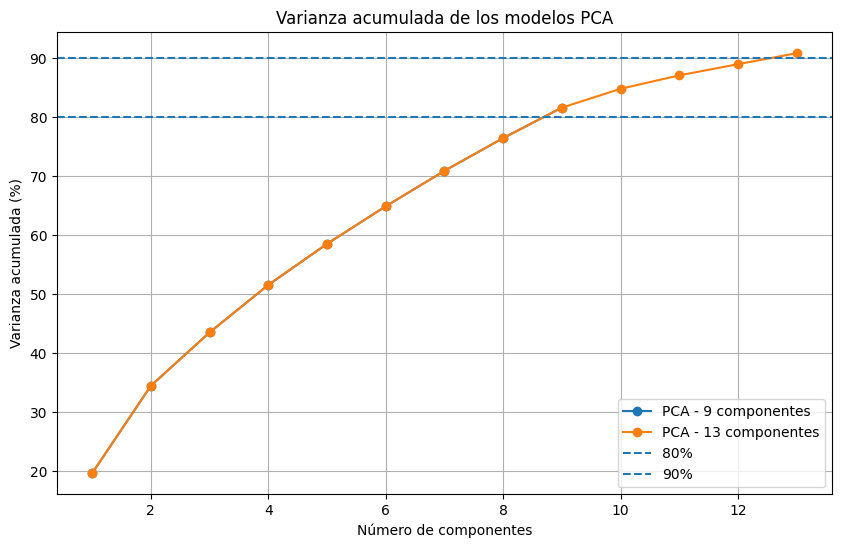

In [158]:
# PCA de 9 componentes
varianza_9 = pca1.explained_variance_ratio_
acumulada_9 = np.cumsum(varianza_9)

# PCA de 13 componentes
varianza_13 = pca2.explained_variance_ratio_
acumulada_13 = np.cumsum(varianza_13)

plt.figure(figsize=(10, 6))

plt.plot(
    range(1, 10),
    acumulada_9 * 100,
    marker="o",
    label="PCA - 9 componentes"
)

plt.plot(
    range(1, 14),
    acumulada_13 * 100,
    marker="o",
    label="PCA - 13 componentes"
)

plt.axhline(
    80,
    linestyle="--",
    label="80%"
)

plt.axhline(
    90,
    linestyle="--",
    label="90%"
)

plt.xlabel("Número de componentes")
plt.ylabel("Varianza acumulada (%)")
plt.title("Varianza acumulada de los modelos PCA")
plt.legend()
plt.grid(True)
plt.show()

Análisis de componentes

In [159]:
loadings = pd.DataFrame(
    pca1.components_.T,
    index=X_pca.columns,
    columns=[f"PC{i}" for i in range(1, 10)]
)

for pc in loadings.columns:
    print(f"\n{pc}")
    print(
        loadings[pc]
        .sort_values(key=abs, ascending=False)
        .head(10)
    )


PC1
num__energy              0.522030
num__loudness            0.506707
num__acousticness       -0.451966
num__valence             0.264886
num__danceability        0.218744
num__speechiness         0.218112
num__instrumentalness   -0.201598
num__tempo               0.192058
num__liveness            0.108866
num__mode               -0.071653
Name: PC1, dtype: float64

PC2
num__duration_min         0.616080
ord__duration_category    0.609547
num__valence             -0.291562
num__instrumentalness     0.235927
num__danceability        -0.205429
num__acousticness        -0.170091
num__speechiness         -0.114689
num__energy               0.105205
num__tempo                0.074615
num__mode                -0.067027
Name: PC2, dtype: float64

PC3
num__danceability         0.567084
num__valence              0.423668
num__liveness            -0.395679
ord__duration_category    0.266096
num__duration_min         0.256708
num__tempo               -0.237581
num__speechiness         -0.22653

In [160]:
df_muestra, _ = train_test_split(
    df_pca_1,
    train_size=5000,
    stratify=df_pca_1["popularity_category"],
    random_state=42
)

In [161]:
pca3 = PCA(n_components=3)

X_pca_df3 = pca3.fit_transform(X_pca)

print("Varianza explicada:")
for i, varianza in enumerate(pca3.explained_variance_ratio_, start=1):
    print(f"PC{i}: {varianza:.2%}")

print(f"\nVarianza acumulada: {pca3.explained_variance_ratio_.sum():.2%}")

Varianza explicada:
PC1: 19.70%
PC2: 14.80%
PC3: 9.03%

Varianza acumulada: 43.53%


In [162]:
df_pca_3 = pd.DataFrame(
    X_pca_df3,
    columns=[f"PC{i}" for i in range(1, pca3.n_components_ + 1)],
    index=df.index
)

df_pca_3["popularity_category"] = df["popularity_category"]

In [163]:
df_pca_3.head()

,PC1,PC2,PC3,popularity_category
0,-0.200809,-1.375739,1.229657,1
1,-0.070853,-0.885718,0.933779,0
2,-0.143451,1.765934,-0.788070,2
3,1.108933,-0.815601,0.887455,0
4,-2.034280,-1.121345,0.131627,2


In [164]:
df_muestra_3, _ = train_test_split(
    df_pca_3,
    train_size=5000,
    stratify=df_pca_3["popularity_category"],
    random_state=42
)

print(f"Canciones seleccionadas: {len(df_muestra_3)}")

Canciones seleccionadas: 5000


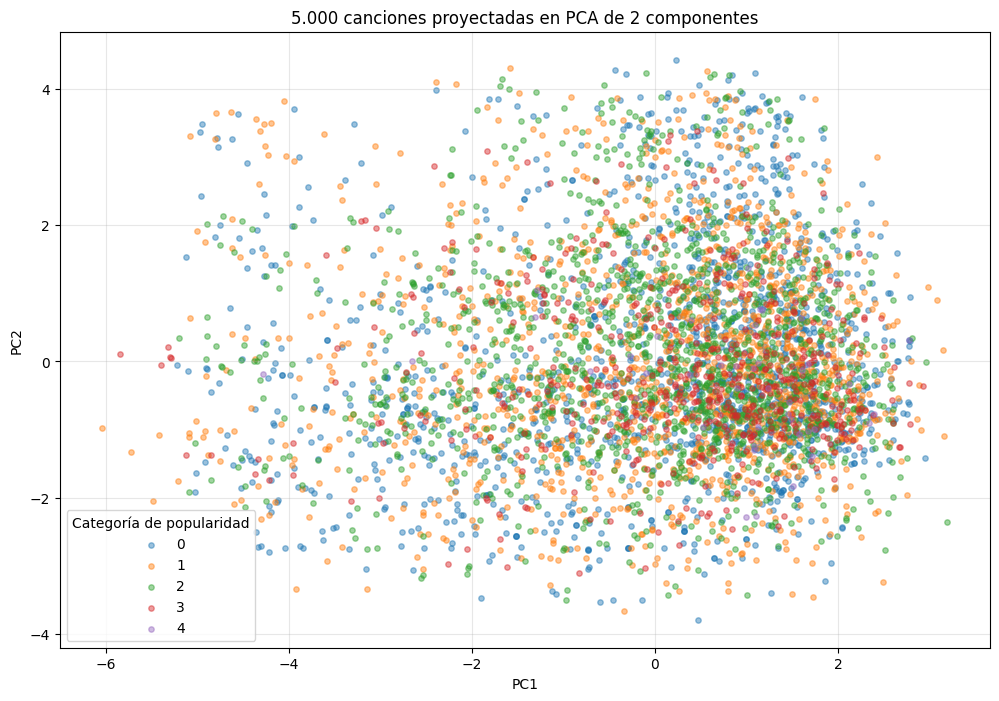

In [165]:
plt.figure(figsize=(12, 8))

for categoria in sorted(df_muestra_3["popularity_category"].unique()):

    datos = df_muestra_3[
        df_muestra_3["popularity_category"] == categoria
    ]

    plt.scatter(
        datos["PC1"],
        datos["PC2"],
        alpha=0.45,
        s=15,
        label=categoria
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("5.000 canciones proyectadas en PCA de 2 componentes")
plt.legend(title="Categoría de popularidad")
plt.grid(True, alpha=0.3)
plt.show()

# Graficación en tres dimensiones de PCA 3

In [166]:
fig = px.scatter_3d(
    df_muestra_3,
    x="PC1",
    y="PC2",
    z="PC3",
    color="popularity_category",

    hover_data={
        "PC1": ":.3f",
        "PC2": ":.3f",
        "PC3": ":.3f",
        "popularity_category": True
    },

    title="PCA de 3 componentes — 5.000 canciones",

    labels={
        "PC1": "Componente Principal 1",
        "PC2": "Componente Principal 2",
        "PC3": "Componente Principal 3",
        "popularity_category": "Popularidad"
    },

    opacity=0.6
)

fig.update_traces(
    marker=dict(size=3)
)

fig.update_layout(
    width=1000,
    height=800
)

fig.show()

In [167]:
df_muestra_pca_1, _ = train_test_split(
    df_pca_1,
    train_size=5000,
    stratify=df_pca_1["popularity_category"],
    random_state=42
)

fig = px.scatter_3d(
    df_muestra_pca_1,
    x="PC1",
    y="PC2",
    z="PC3",
    color="popularity_category",
    hover_data={
        "PC1": ":.3f",
        "PC2": ":.3f",
        "PC3": ":.3f",
        "PC4": ":.3f",
        "PC5": ":.3f",
        "PC6": ":.3f",
        "PC7": ":.3f",
        "PC8": ":.3f",
        "PC9": ":.3f",
        "popularity_category": True
    },
    title="PCA de 9 componentes — Proyección 3D según popularidad",
    labels={
        "PC1": "Componente Principal 1",
        "PC2": "Componente Principal 2",
        "PC3": "Componente Principal 3",
        "popularity_category": "Popularidad"
    },
    opacity=0.6
)

fig.update_traces(
    marker=dict(size=3)
)

fig.update_layout(
    width=1000,
    height=800
)

fig.show()

In [201]:
df_muestra_pca_2, _ = train_test_split(
    df_pca_2,
    train_size=5000,
    stratify=df_pca_2["popularity_category"],
    random_state=42
)

fig = px.scatter_3d(
    df_muestra_pca_2,
    x="PC1",
    y="PC2",
    z="PC3",
    color="popularity_category",
    hover_data={
        "PC1": ":.3f",
        "PC2": ":.3f",
        "PC3": ":.3f",
        "PC4": ":.3f",
        "PC5": ":.3f",
        "PC6": ":.3f",
        "PC7": ":.3f",
        "PC8": ":.3f",
        "PC9": ":.3f",
        "PC10": ":.3f",
        "PC11": ":.3f",
        "PC12": ":.3f",
        "PC13": ":.3f",
        "popularity_category": True
    },
    title="PCA de 13 componentes — Proyección 3D según popularidad",
    labels={
        "PC1": "Componente Principal 1",
        "PC2": "Componente Principal 2",
        "PC3": "Componente Principal 3",
        "popularity_category": "Popularidad"
    },
    opacity=0.6
)

fig.update_traces(
    marker=dict(size=3)
)

fig.update_layout(
    width=1000,
    height=800
)

fig.show()

---

# Proceso de K-means y Clusters

Buscando el número adecuado de clusters

In [169]:
# 9 Dimensiones
X_cluster_1 = df_pca_1.drop(columns="popularity_category")

# 13 Dimensiones
X_cluster_2 = df_pca_2.drop(columns="popularity_category")

# 3 Dimensiones
X_cluster_3 = df_pca_3.drop(columns="popularity_category")

Puesto que nuestro dataset contiene muchos datos, silhouette Score **no ejecutará** puesto que es costoso computacionalmente, por lo qué se creará un muestreo estratificado.

In [170]:
df_muestra_pca9, _ = train_test_split(
    df_pca_1,
    train_size=5000,
    stratify=df_pca_1["popularity_category"],
    random_state=42
)

df_muestra_pca13, _ = train_test_split(
    df_pca_2,
    train_size=5000,
    stratify=df_pca_2["popularity_category"],
    random_state=42
)

In [171]:
print("Distribución original PCA 9:")
print(df_pca_1["popularity_category"].value_counts(normalize=True))

print("\nDistribución muestra PCA 9:")
print(df_muestra_pca9["popularity_category"].value_counts(normalize=True))

print("\nDistribución original 13:")
print(df_pca_2["popularity_category"].value_counts(normalize=True))

print("\nDistribución muestra 13:")
print(df_muestra_pca13["popularity_category"].value_counts(normalize=True))

Distribución original PCA 9:
popularity_category
0    0.297189
2    0.291634
1    0.291623
3    0.111156
4    0.008398
Name: proportion, dtype: float64

Distribución muestra PCA 9:
popularity_category
0    0.2972
1    0.2916
2    0.2916
3    0.1112
4    0.0084
Name: proportion, dtype: float64

Distribución original 13:
popularity_category
0    0.297189
2    0.291634
1    0.291623
3    0.111156
4    0.008398
Name: proportion, dtype: float64

Distribución muestra 13:
popularity_category
0    0.2972
1    0.2916
2    0.2916
3    0.1112
4    0.0084
Name: proportion, dtype: float64


Creación de muestras Silhouette

In [172]:
X_muestra_pca9 = df_muestra_pca9[
    [f"PC{i}" for i in range(1, 10)]
]

X_muestra_pca13 = df_muestra_pca13[
    [f"PC{i}" for i in range(1, 14)]
]

Análisis de parámetros k para el cluster

In [ ]:
X_muestra_pca9 = df_muestra_pca9[
    [f"PC{i}" for i in range(1, 10)]
]

X_muestra_pca13 = df_muestra_pca13[
    [f"PC{i}" for i in range(1, 14)]
]


k_values = range(2, 9)


resultados_pca9 = []
resultados_pca13 = []

for k in k_values:

    # PCA 9

    kmeans_pca9 = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels_pca9 = kmeans_pca9.fit_predict(
        X_muestra_pca9
    )

    resultados_pca9.append({
        "K": k,
        "Inertia": kmeans_pca9.inertia_,
        "Silhouette": silhouette_score(
            X_muestra_pca9,
            labels_pca9
        ),
        "Calinski-Harabasz": calinski_harabasz_score(
            X_muestra_pca9,
            labels_pca9
        ),
        "Davies-Bouldin": davies_bouldin_score(
            X_muestra_pca9,
            labels_pca9
        )
    })

    # PCA 13

    kmeans_pca13 = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels_pca13 = kmeans_pca13.fit_predict(
        X_muestra_pca13
    )

    resultados_pca13.append({
        "K": k,
        "Inertia": kmeans_pca13.inertia_,
        "Silhouette": silhouette_score(
            X_muestra_pca13,
            labels_pca13
        ),
        "Calinski-Harabasz": calinski_harabasz_score(
            X_muestra_pca13,
            labels_pca13
        ),
        "Davies-Bouldin": davies_bouldin_score(
            X_muestra_pca13,
            labels_pca13
        )
    })

resultados_pca9 = pd.DataFrame(resultados_pca9)
resultados_pca13 = pd.DataFrame(resultados_pca13)

print("RESULTADOS — PCA 9")
print(resultados_pca9.round(4))

print("\nRESULTADOS — PCA 13")
print(resultados_pca13.round(4))

RESULTADOS — PCA 9
   K     Inertia  Silhouette  Calinski-Harabasz  Davies-Bouldin
0  2  49708.5329      0.1825          1001.9228          1.9512
1  3  44234.1549      0.1476           872.0618          2.0618
2  4  41196.8263      0.1308           746.8896          2.0977
3  5  38874.8674      0.1238           668.1014          2.0092
4  6  37041.0083      0.1213           610.2769          1.9101
5  7  35457.2902      0.1246           568.3414          1.9180
6  8  34022.7116      0.1204           537.6571          1.9273

RESULTADOS — PCA 13
   K     Inertia  Silhouette  Calinski-Harabasz  Davies-Bouldin
0  2  56463.6242      0.1660           882.7240          2.0956
1  3  50981.3005      0.1308           757.4078          2.2230
2  4  47943.7864      0.1145           642.3290          2.2734
3  5  45618.5557      0.1062           569.8592          2.2019
4  6  43850.6972      0.1065           514.4313          2.2154
5  7  42026.8915      0.1024           483.3211          2.1568


Gracias al análisis de las distintas métricas, podemos llegar a la conclusión que aunque PCA 13 conserva aproximadamente un **90,81% de la varianza** esos cuatros parámetros extra respecto a PCA 9 **NO CONTRIBUYEN A FORMAR GRUPOS MÁS SEPARADOS** es más **PERJUDICA AL MODELO**

# Inercia - Método del codo

Con este gráfico buscamos **encontrar el punto codo** o sea el punto de inflexión.

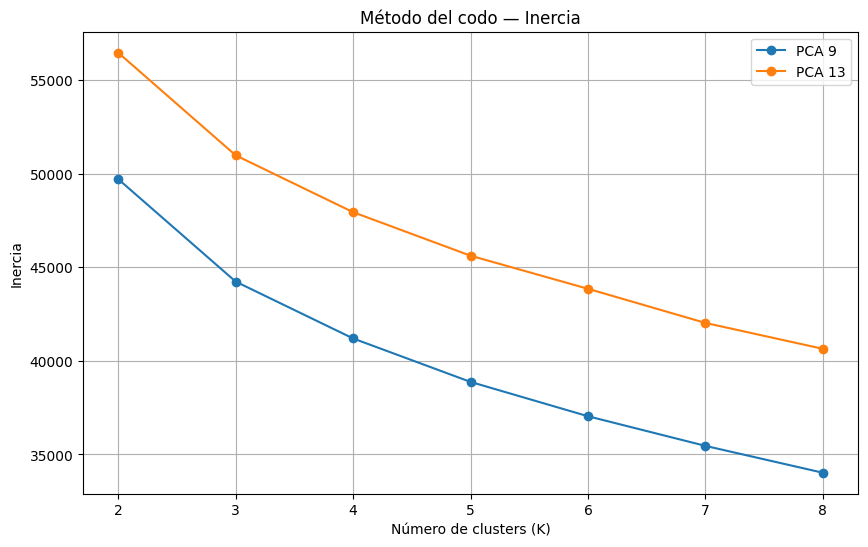

In [174]:
plt.figure(figsize=(10, 6))

plt.plot(
    resultados_pca9["K"],
    resultados_pca9["Inertia"],
    marker="o",
    label="PCA 9"
)

plt.plot(
    resultados_pca13["K"],
    resultados_pca13["Inertia"],
    marker="o",
    label="PCA 13"
)

plt.title("Método del codo — Inercia")
plt.xlabel("Número de clusters (K)")
plt.ylabel("Inercia")
plt.xticks(k_values)
plt.legend()
plt.grid(True)

plt.show()

# Silhouette Score

Con este gráfico buscamos **el Silhouette Score más alto** con la menor cantidad de clusters k.

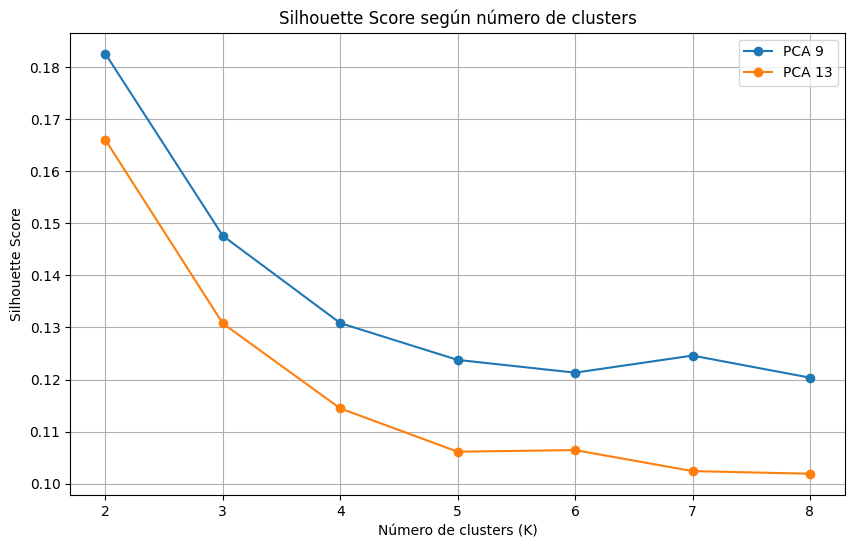

In [175]:
plt.figure(figsize=(10, 6))

plt.plot(
    resultados_pca9["K"],
    resultados_pca9["Silhouette"],
    marker="o",
    label="PCA 9"
)

plt.plot(
    resultados_pca13["K"],
    resultados_pca13["Silhouette"],
    marker="o",
    label="PCA 13"
)

plt.title("Silhouette Score según número de clusters")
plt.xlabel("Número de clusters (K)")
plt.ylabel("Silhouette Score")
plt.xticks(k_values)
plt.legend()
plt.grid(True)

plt.show()

# Calinski-Harabasz

Con este gráfico buscamos **el valor más alto Calinski-Harabasz** con la menor cantidad de clusters k.

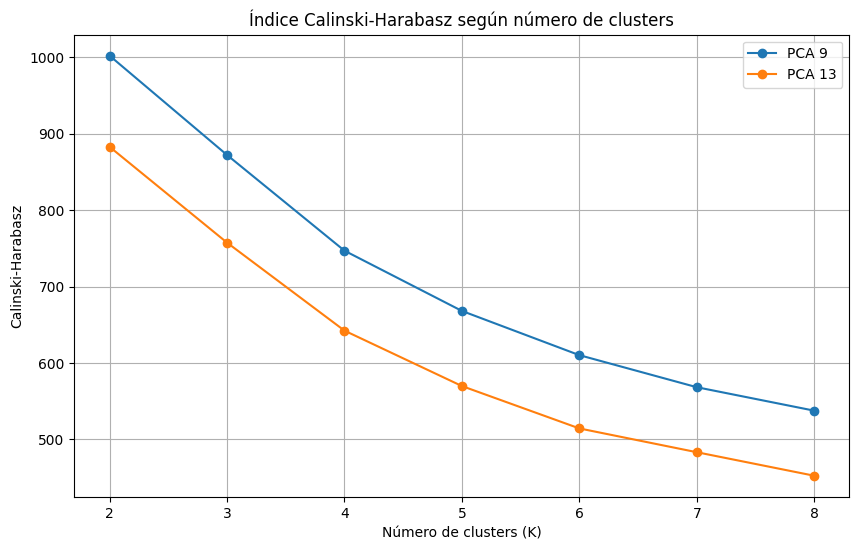

In [176]:
plt.figure(figsize=(10, 6))

plt.plot(
    resultados_pca9["K"],
    resultados_pca9["Calinski-Harabasz"],
    marker="o",
    label="PCA 9"
)

plt.plot(
    resultados_pca13["K"],
    resultados_pca13["Calinski-Harabasz"],
    marker="o",
    label="PCA 13"
)

plt.title("Índice Calinski-Harabasz según número de clusters")
plt.xlabel("Número de clusters (K)")
plt.ylabel("Calinski-Harabasz")
plt.xticks(k_values)
plt.legend()
plt.grid(True)

plt.show()

# Davies-Bouldin

Con este gráfico buscamos **Encontrar el menor valor posible de Davies-Bouldin** con la menor cantidad de clusters k.

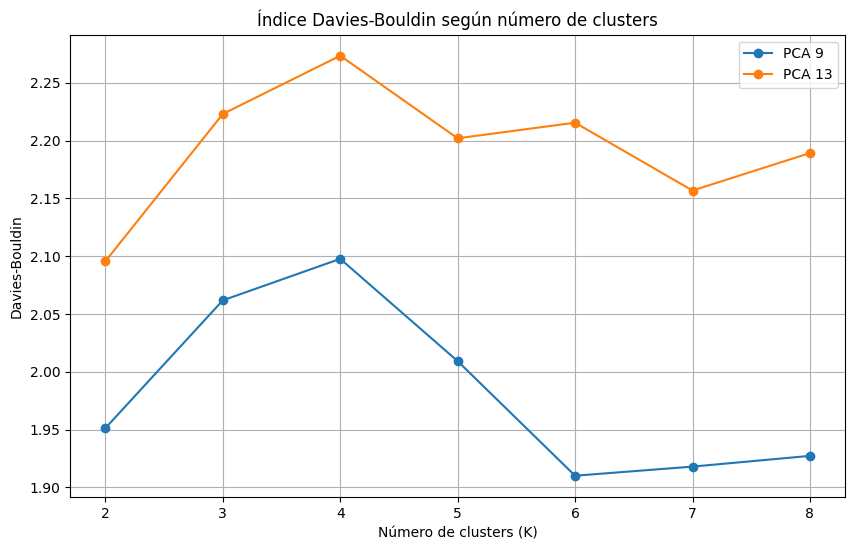

In [177]:
plt.figure(figsize=(10, 6))

plt.plot(
    resultados_pca9["K"],
    resultados_pca9["Davies-Bouldin"],
    marker="o",
    label="PCA 9"
)

plt.plot(
    resultados_pca13["K"],
    resultados_pca13["Davies-Bouldin"],
    marker="o",
    label="PCA 13"
)

plt.title("Índice Davies-Bouldin según número de clusters")
plt.xlabel("Número de clusters (K)")
plt.ylabel("Davies-Bouldin")
plt.xticks(k_values)
plt.legend()
plt.grid(True)

plt.show()

Redeclaración de cluster para PCA 9

In [178]:
X_cluster = df_pca_1[
    [f"PC{i}" for i in range(1, 10)]
]

kmeans_pca9 = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

df_pca_1["cluster"] = kmeans_pca9.fit_predict(X_cluster)

print("Cantidad de clusters:", kmeans_pca9.n_clusters)
print("Dimensiones de los centroides:", kmeans_pca9.cluster_centers_.shape)

Cantidad de clusters: 5
Dimensiones de los centroides: (5, 9)


PCA 9 fue seleccionado por presentar una mejor estructura de clustering que PCA 13 en las métricas evaluadas. 

Posteriormente, se seleccionó **K=5** como un compromiso entre la calidad interna del agrupamiento y la necesidad de obtener una segmentación suficientemente granular para caracterizar distintos perfiles musicales y analizar posteriormente su distribución respecto de las categorías de popularidad. 

In [179]:
df_pca_1.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,popularity_category,cluster
0,-0.200809,-1.375739,1.229657,0.260928,0.175410,1.301302,-0.213395,0.526588,0.631094,1,1
1,-0.070853,-0.885718,0.933779,0.659522,-0.334985,1.296782,0.063861,0.117424,0.242782,0,1
2,-0.143451,1.765934,-0.788070,0.426808,-0.482869,1.772724,-0.813168,0.414526,-1.460656,2,3
3,1.108933,-0.815601,0.887455,-1.884844,-0.158095,0.821274,-0.896440,-0.363621,-0.273614,0,2
4,-2.034280,-1.121345,0.131627,-1.367931,-1.711352,-0.524165,3.779628,-1.182260,1.592352,2,0


In [180]:
df_pca_1["cluster"].value_counts(
    normalize=True
).sort_index() * 100

cluster
0    18.545907
1    27.391252
2    20.111972
3    18.014702
4    15.936167
Name: proportion, dtype: float64

In [181]:
centroides = pd.DataFrame(
    kmeans_pca9.cluster_centers_,
    columns=[f"PC{i}" for i in range(1, 10)]
)

centroides.index.name = "cluster"

display(centroides.round(3))

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9
cluster,,,,,,,,,
0,-2.827,-0.405,-0.197,-0.028,0.078,0.078,0.135,-0.043,-0.061
1,0.549,-0.889,0.516,0.617,-0.134,0.073,-0.116,0.431,0.071
2,0.881,-0.481,0.394,-1.035,0.194,-0.206,-0.130,-0.771,-0.037
3,-0.033,2.123,0.360,0.032,-0.086,-0.073,0.029,0.128,0.089
4,1.271,0.206,-1.561,0.241,-0.008,0.126,0.174,0.137,-0.105


In [182]:
conteo_clusters = (
    df_pca_1["cluster"]
    .value_counts()
    .sort_index()
)

porcentaje_clusters = (
    df_pca_1["cluster"]
    .value_counts(normalize=True)
    .sort_index() * 100
)

resumen_clusters = pd.DataFrame({
    "Cantidad": conteo_clusters,
    "Porcentaje": porcentaje_clusters
})

display(resumen_clusters.round(2))

,Cantidad,Porcentaje
cluster,,
0,16828,18.55
1,24854,27.39
2,18249,20.11
3,16346,18.01
4,14460,15.94


¿Qué significa cada componente?

In [183]:
for pc in loadings.columns:
    print(f"\n{pc}")
    display(
        loadings[pc]
        .sort_values(key=abs, ascending=False)
        .head(5)
    )


PC1


num__energy          0.522030
num__loudness        0.506707
num__acousticness   -0.451966
num__valence         0.264886
num__danceability    0.218744
Name: PC1, dtype: float64


PC2


num__duration_min         0.616080
ord__duration_category    0.609547
num__valence             -0.291562
num__instrumentalness     0.235927
num__danceability        -0.205429
Name: PC2, dtype: float64


PC3


...

num__tempo           0.622228
num__speechiness     0.568301
num__acousticness    0.273936
num__loudness       -0.242115
num__valence         0.185402
Name: PC7, dtype: float64


PC8


num__mode                0.712181
num__key                 0.408162
num__speechiness         0.335719
num__instrumentalness    0.328048
num__tempo              -0.239811
Name: PC8, dtype: float64


PC9


num__instrumentalness    0.570154
num__liveness            0.461894
num__speechiness        -0.428804
num__valence             0.405090
num__danceability        0.198071
Name: PC9, dtype: float64

In [184]:
fig = px.scatter_3d(
    df_pca_1,
    x="PC1",
    y="PC2",
    z="PC3",
    color="cluster",
    title="Clusters K-Means sobre PCA 9",
    labels={
        "PC1": "Componente Principal 1",
        "PC2": "Componente Principal 2",
        "PC3": "Componente Principal 3",
        "cluster": "Cluster"
    },
    opacity=0.5
)

fig.update_traces(
    marker=dict(size=3)
)

fig.update_layout(
    width=1000,
    height=800
)

fig.show()

In [200]:
tabla_popularidad = pd.crosstab(
    df_pca_1["cluster"],
    df_pca_1["popularity_category"],
    normalize="index"
) * 100

print(tabla_popularidad.round(2))

popularity_category      0      1      2      3     4
cluster                                              
0                    32.68  29.86  29.07   8.19  0.21
1                    29.99  28.16  27.54  13.06  1.26
2                    28.72  25.46  29.30  15.08  1.43
3                    29.66  28.19  32.61   8.99  0.54
4                    27.13  35.84  27.99   8.59  0.45


Observaciones:

1-) El Cluster 2 es el que representa la mayor proporción de canciones altamente populares:

* 15,08% Alta + 1,43% Muy alta = 16,51%

    Seguido por el Cluster 1 con:

* 13,06% Alta + 1,26% Muy alta = 14,32%


2-) El Cluster 0 concentra la mayor proporción de canciones de popularidad Muy Baja (32,68%).


3-) El Cluster 4 destaca por tener la mayor porporción de canciones Baja (35,84%).

---

# Interpretación de clusters

In [186]:
centroides_originales = pd.DataFrame(
    kmeans_pca9.cluster_centers_ @ pca1.components_,
    columns=features_pca,
    index=[f"Cluster {i}" for i in range(kmeans_pca9.n_clusters)]
)

display(centroides_originales.round(3))

,bin__track_genre_0,bin__track_genre_1,bin__track_genre_2,bin__track_genre_3,bin__track_genre_4,bin__track_genre_5,bin__track_genre_6,ord__duration_category,num__danceability,num__energy,num__key,num__loudness,num__mode,num__speechiness,num__acousticness,num__instrumentalness,num__liveness,num__valence,num__tempo,num__duration_min
Cluster 0,-0.048,-0.041,-0.007,-0.082,0.081,0.028,0.019,-0.353,-0.665,-1.524,-0.110,-1.449,0.191,-0.447,1.394,0.428,-0.204,-0.702,-0.438,-0.350
Cluster 1,0.039,0.015,-0.008,-0.029,-0.006,-0.001,0.005,-0.371,0.554,0.172,-0.078,0.306,0.750,-0.055,-0.107,-0.430,-0.132,0.669,-0.122,-0.384
Cluster 2,0.013,0.049,-0.007,0.017,0.031,-0.039,-0.025,-0.248,0.567,0.297,0.230,0.367,-1.331,0.217,-0.276,-0.318,-0.089,0.430,-0.100,-0.250
Cluster 3,-0.046,0.012,0.043,0.077,-0.042,0.021,0.019,1.381,-0.180,0.163,0.004,-0.034,-0.035,-0.305,-0.343,0.559,-0.147,-0.449,0.070,1.394
Cluster 4,0.024,-0.054,-0.017,0.035,-0.076,-0.005,-0.022,-0.200,-0.690,0.917,-0.033,0.736,0.205,0.685,-0.703,0.010,0.743,-0.367,0.766,-0.193


Las columnas `track_genre` quedarán en el modelo, pero no los utilizaremos para identificar grupos, servirán para factores comparativos nada más.

In [187]:
features_musicales = [
    "ord__duration_category",
    "num__danceability",
    "num__energy",
    "num__key",
    "num__loudness",
    "num__mode",
    "num__speechiness",
    "num__acousticness",
    "num__instrumentalness",
    "num__liveness",
    "num__valence",
    "num__tempo",
    "num__duration_min"
]

perfil_musical = centroides_originales[features_musicales]

display(perfil_musical.round(3))

,ord__duration_category,num__danceability,num__energy,num__key,num__loudness,num__mode,num__speechiness,num__acousticness,num__instrumentalness,num__liveness,num__valence,num__tempo,num__duration_min
Cluster 0,-0.353,-0.665,-1.524,-0.110,-1.449,0.191,-0.447,1.394,0.428,-0.204,-0.702,-0.438,-0.350
Cluster 1,-0.371,0.554,0.172,-0.078,0.306,0.750,-0.055,-0.107,-0.430,-0.132,0.669,-0.122,-0.384
Cluster 2,-0.248,0.567,0.297,0.230,0.367,-1.331,0.217,-0.276,-0.318,-0.089,0.430,-0.100,-0.250
Cluster 3,1.381,-0.180,0.163,0.004,-0.034,-0.035,-0.305,-0.343,0.559,-0.147,-0.449,0.070,1.394
Cluster 4,-0.200,-0.690,0.917,-0.033,0.736,0.205,0.685,-0.703,0.010,0.743,-0.367,0.766,-0.193


Identificación de las **características más distintivas de cada cluster**

In [188]:
for cluster in perfil_musical.index:
    print(f"\n{cluster}")
    
    print(
        perfil_musical.loc[cluster]
        .sort_values(key=abs, ascending=False)
        .head(6)
        .round(3)
    )


Cluster 0
num__energy         -1.524
num__loudness       -1.449
num__acousticness    1.394
num__valence        -0.702
num__danceability   -0.665
num__speechiness    -0.447
Name: Cluster 0, dtype: float64

Cluster 1
num__mode                 0.750
num__valence              0.669
num__danceability         0.554
num__instrumentalness    -0.430
num__duration_min        -0.384
ord__duration_category   -0.371
Name: Cluster 1, dtype: float64

Cluster 2
num__mode               -1.331
num__danceability        0.567
num__valence             0.430
num__loudness            0.367
num__instrumentalness   -0.318
num__energy              0.297
Name: Cluster 2, dtype: float64

Cluster 3
num__duration_min         1.394
ord__duration_category    1.381
num__instrumentalness     0.559
num__valence             -0.449
num__acousticness        -0.343
num__speechiness         -0.305
Name: Cluster 3, dtype: float64

Cluster 4
num__energy          0.917
num__tempo           0.766
num__liveness        0.743
num_

## Interpretación de cada cluster

### Cluster 0 — Perfil acústico y de baja intensidad

Características principales:

* Energy: −1.524
* Loudness: −1.449
* Acousticness: +1.394
* Valence: −0.702
* Danceability: −0.665
* Speechiness: −0.447

Canciones predominantemente acústicas, de baja intensidad sonora y menor carácter bailable, con una tendencia hacia una valencia más baja.

**Posee la mayor proporción de canciones con popularidad Muy baja: 32,68%.**

### Cluster 1 — Perfil bailable y positivo

Características principales:

* Mode: +0.750
* Valence: +0.669
* Danceability: +0.554
* Instrumentalness: −0.430
* Duration: −0.384
* Duration category: -0.371

Canciones relativamente bailables y de valencia positiva, con menor presencia instrumental y una duración ligeramente inferior al promedio.

**Posee la segunda mayor proporción de canciones con popularidad Alta + Muy alta: 14,31%.**

### Cluster 2 — Perfil bailable y positivo de menor modalidad

Características:

* Mode: −1.331
* Danceability: +0.567
* Valence: +0.430
* Loudness: +0.367
* Instrumentalness: −0.318
* Energy: +0.297

Aquí la característica más diferenciadora es `mode`, seguida por `danceability`.

Canciones relativamente bailables y positivas, con mayor intensidad sonora y energética que el promedio, pero con una marcada diferencia en la variable de modalidad.

**Posee la mayor proporción de canciones con popularidad Alta + Muy alta: 16,51%.**


### Cluster 3 — Perfil instrumental y de mayor duración

Características:

* Duration: +1.394
* Duration category: +1.381
* Instrumentalness: +0.559
* Valence: −0.449
* Acousticness: −0.343
* Speechiness: −0.305

Aquí hay una característica especialmente clara:

la duración de las canciones.

Tanto `duration_min` como `duration_category` tienen valores muy superiores al promedio

Canciones considerablemente más largas que el promedio, con mayor presencia instrumental y una valencia ligeramente inferior.

**Cluster con mayor presencia relativa de canciones altamente populares:**

**Su proporción de canciones con popularidad Alta + Muy alta es de 9,53%.**

### Cluster 4 — Perfil energético y dinámico

Características:

* Energy: +0.917
* Tempo: +0.766
* Liveness: +0.743
* Loudness: +0.736
* Acousticness: −0.703
* Danceability: −0.690

Este cluster presenta un contraste interesante:

alta energía;
mayor tempo;
mayor liveness;
mayor loudness;
baja acousticness;
pero también menor danceability.


Canciones energéticas y de mayor intensidad sonora, con tempos más elevados y mayor presencia de características asociadas a interpretaciones en vivo, aunque con una menor tendencia a ser bailables.

**Su proporción Alta + Muy alta es: 9,54%**

**por lo que se encuentra en una posición intermedia-baja respecto a los demás clusters.**

## Interpretación de los perfiles musicales

A partir de los centroides de K-Means reconstruidos en el espacio de las variables originales, se identificaron cinco perfiles musicales diferenciados. 

El Cluster 0 se caracteriza principalmente por una baja energía y loudness, junto con una elevada acousticness, configurando un perfil acústico y de baja intensidad. 

El Cluster 1 presenta mayores niveles de danceability y valence, por lo que puede asociarse con canciones relativamente bailables y de carácter positivo. 

El Cluster 2 también presenta mayores niveles de danceability y valence, acompañado de una mayor intensidad sonora, aunque se diferencia principalmente por su comportamiento en la variable mode. 

El Cluster 3 se caracteriza por canciones de mayor duración y una mayor presencia instrumental.

Finalmente, el Cluster 4 presenta altos niveles de energy, tempo, liveness y loudness, junto con una menor acousticness y danceability, representando un perfil energético y dinámico.

Al comparar estos perfiles con las categorías de popularidad, el Cluster 3 presenta la mayor proporción relativa de canciones clasificadas como Alta o Muy alta, con un 16,26%, seguido por el Cluster 1 con un 14,56%. 

En contraste, los Clusters 0 y 2 presentan las menores proporciones, con 8,53% y 8,70%, respectivamente. 

Estos resultados permiten observar diferencias en la distribución de la popularidad entre los perfiles musicales identificados, sin embargo, no permiten establecer una relación causal entre las características musicales y la popularidad.

# Análisis de distribución por categorías con la popularidad original

Crearemos un resumen de popularidad por cluster

In [189]:
df_analisis = df.copy()

df_analisis["cluster"] = df_pca_1["cluster"]

resumen_popularidad_cluster = (
    df_analisis
    .groupby("cluster")
    .agg(
        cantidad=("popularity_category", "size"),
        media_popularidad=("popularity_category", "mean"),
        mediana_popularidad=("popularity_category", "median"),
        desviacion_std=("popularity_category", "std")
    )
    .round(2)
)

display(resumen_popularidad_cluster)

,cantidad,media_popularidad,mediana_popularidad,desviacion_std
cluster,,,,
0,16828,1.13,1.0,0.97
1,24854,1.27,1.0,1.07
2,18249,1.35,1.0,1.09
3,16346,1.23,1.0,0.99
4,14460,1.19,1.0,0.95


In [190]:
resumen_ordenado = (
    resumen_popularidad_cluster
    .sort_values("media_popularidad", ascending=False)
)

display(resumen_ordenado)

,cantidad,media_popularidad,mediana_popularidad,desviacion_std
cluster,,,,
2,18249,1.35,1.0,1.09
1,24854,1.27,1.0,1.07
3,16346,1.23,1.0,0.99
4,14460,1.19,1.0,0.95
0,16828,1.13,1.0,0.97


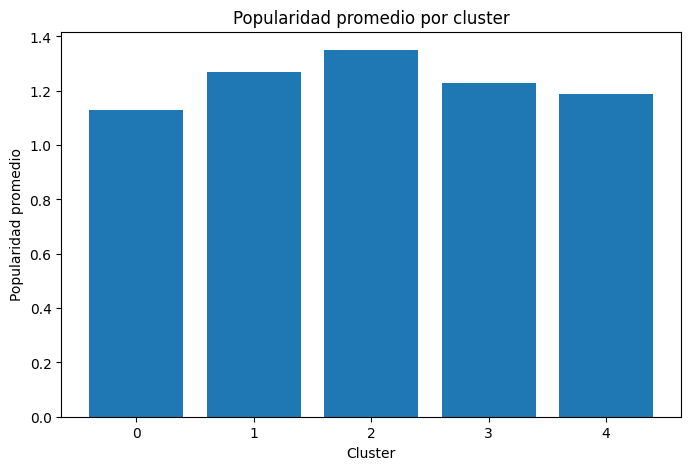

In [191]:
plt.figure(figsize=(8, 5))

plt.bar(
    resumen_popularidad_cluster.index,
    resumen_popularidad_cluster["media_popularidad"]
)

plt.xlabel("Cluster")
plt.ylabel("Popularidad promedio")
plt.title("Popularidad promedio por cluster")

plt.show()

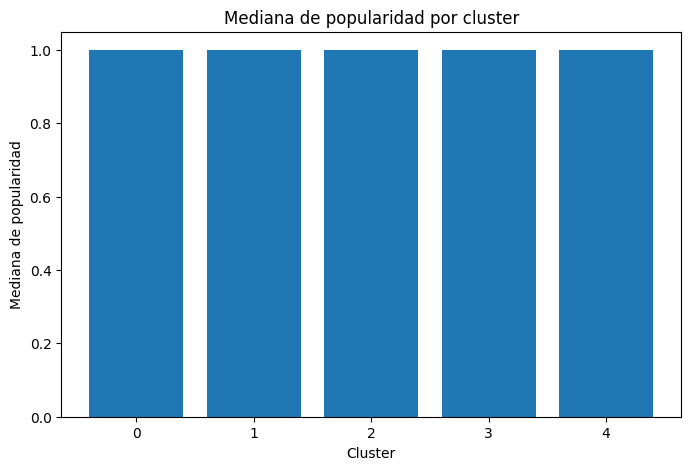

In [192]:
plt.figure(figsize=(8, 5))

plt.bar(
    resumen_popularidad_cluster.index,
    resumen_popularidad_cluster["mediana_popularidad"]
)

plt.xlabel("Cluster")
plt.ylabel("Mediana de popularidad")
plt.title("Mediana de popularidad por cluster")

plt.show()

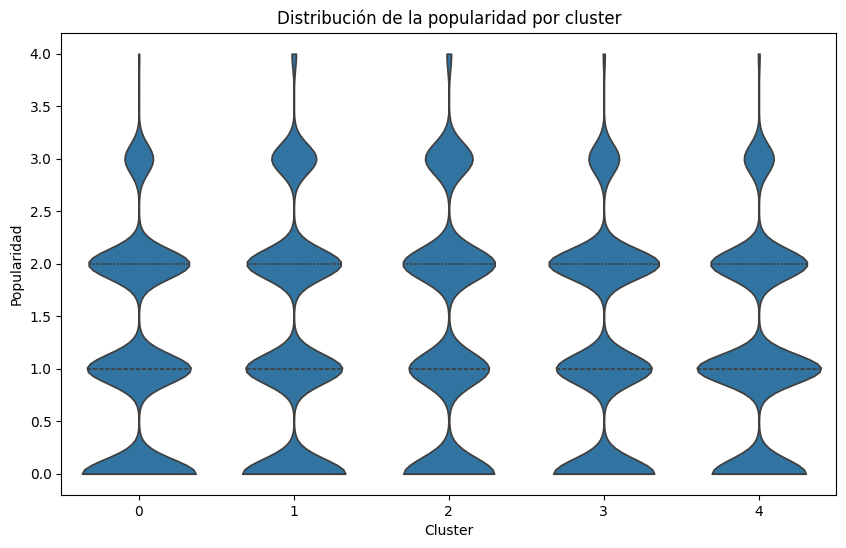

In [193]:
plt.figure(figsize=(10, 6))

sns.violinplot(
    data=df_analisis,
    x="cluster",
    y="popularity_category",
    inner="quartile",
    cut=0
)

plt.title("Distribución de la popularidad por cluster")
plt.xlabel("Cluster")
plt.ylabel("Popularidad")

plt.show()

El gráfico de violín muestra que la distribución de la popularidad se concentra principalmente en valores bajos en los cinco clusters, mientras que las diferencias entre ellos se presentan principalmente en la extensión y densidad de las observaciones hacia valores superiores.

---

# Análisis de popularidad absoluta, proporcional y tamaño absoluto

## ¿Qué cluster presenta el mayor nivel promedio de la categoría de popularidad?

In [194]:
resumen_categoria = (
    df_analisis
    .groupby("cluster")
    .agg(
        cantidad=("popularity_category", "size"),
        promedio_categoria=("popularity_category", "mean"),
        mediana_categoria=("popularity_category", "median"),
        desviacion_std=("popularity_category", "std")
    )
    .round(2)
)

display(resumen_categoria)

,cantidad,promedio_categoria,mediana_categoria,desviacion_std
cluster,,,,
0,16828,1.13,1.0,0.97
1,24854,1.27,1.0,1.07
2,18249,1.35,1.0,1.09
3,16346,1.23,1.0,0.99
4,14460,1.19,1.0,0.95


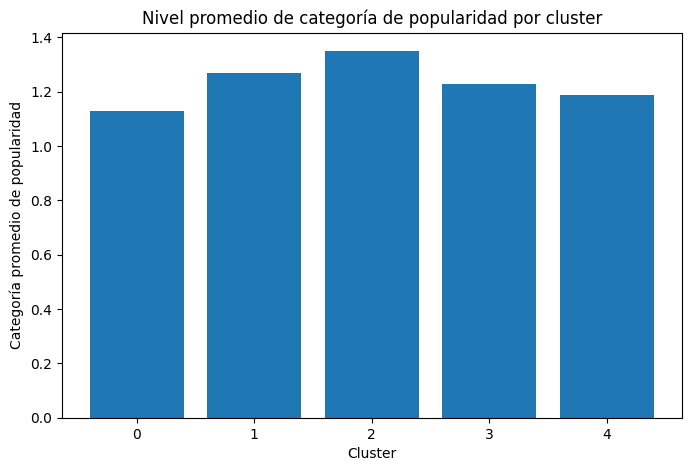

In [195]:
plt.figure(figsize=(8, 5))

plt.bar(
    resumen_categoria.index,
    resumen_categoria["promedio_categoria"]
)

plt.xlabel("Cluster")
plt.ylabel("Categoría promedio de popularidad")
plt.title("Nivel promedio de categoría de popularidad por cluster")

plt.show()

Resultado

El Cluster 2 presenta la mayor popularidad promedio, con 1,35.

Sin embargo, como todos tienen una mediana de 1, no podemos decir que una canción típica del Cluster 2 sea considerablemente más popular. La diferencia de medias parece estar relacionada con una mayor presencia de valores superiores dentro de la distribución.

## ¿Cómo se distribuyen las categorías de popularidad dentro de cada cluster?

In [196]:
tabla_proporcional = pd.crosstab(
    df_analisis["cluster"],
    df_analisis["popularity_category"],
    normalize="index"
) * 100

tabla_proporcional.columns = [
    "Muy baja",
    "Baja",
    "Media",
    "Alta",
    "Muy alta"
]

display(tabla_proporcional.round(2))

,Muy baja,Baja,Media,Alta,Muy alta
cluster,,,,,
0,32.68,29.86,29.07,8.19,0.21
1,29.99,28.16,27.54,13.06,1.26
2,28.72,25.46,29.30,15.08,1.43
3,29.66,28.19,32.61,8.99,0.54
4,27.13,35.84,27.99,8.59,0.45


In [197]:
tabla_proporcional["Alta + Muy alta"] = (
    tabla_proporcional["Alta"] +
    tabla_proporcional["Muy alta"]
)

display(tabla_proporcional.round(2))

,Muy baja,Baja,Media,Alta,Muy alta,Alta + Muy alta
cluster,,,,,,
0,32.68,29.86,29.07,8.19,0.21,8.40
1,29.99,28.16,27.54,13.06,1.26,14.31
2,28.72,25.46,29.30,15.08,1.43,16.51
3,29.66,28.19,32.61,8.99,0.54,9.53
4,27.13,35.84,27.99,8.59,0.45,9.04


## ¿Cuántas canciones de cada categoría existen realmente dentro de cada cluster?

In [198]:
print(
    df_analisis.groupby("cluster")["popularity_category"]
    .value_counts()
    .unstack(fill_value=0)
)

tabla_absoluta = pd.crosstab(
    df_analisis["cluster"],
    df_analisis["popularity_category"]
)

tabla_absoluta.columns = [
    "Muy baja",
    "Baja",
    "Media",
    "Alta",
    "Muy alta"
]

tabla_absoluta["Alta + Muy alta"] = (
    tabla_absoluta["Alta"] +
    tabla_absoluta["Muy alta"]
)

display(tabla_absoluta)

popularity_category     0     1     2     3    4
cluster                                         
0                    5499  5024  4892  1378   35
1                    7453  6999  6845  3245  312
2                    5242  4647  5347  2752  261
3                    4849  4608  5331  1469   89
4                    3923  5183  4047  1242   65


,Muy baja,Baja,Media,Alta,Muy alta,Alta + Muy alta
cluster,,,,,,
0,5499,5024,4892,1378,35,1413
1,7453,6999,6845,3245,312,3557
2,5242,4647,5347,2752,261,3013
3,4849,4608,5331,1469,89,1558
4,3923,5183,4047,1242,65,1307
